In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Read data
traffic1 = pd.read_csv("/content/drive/MyDrive/UK_accident/accidents_2005_to_2007.csv", dtype={'LSOA_of_Accident_Location': str})
traffic2 = pd.read_csv("/content/drive/MyDrive/UK_accident/accidents_2009_to_2011.csv", dtype={'LSOA_of_Accident_Location': str})
traffic3 = pd.read_csv("/content/drive/MyDrive/UK_accident/accidents_2012_to_2014.csv", dtype={'LSOA_of_Accident_Location': str})

In [4]:
df2 = pd.concat([traffic1, traffic2, traffic3], ignore_index = True)

In [5]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1504150 entries, 0 to 1504149
Data columns (total 33 columns):
 #   Column                                       Non-Null Count    Dtype  
---  ------                                       --------------    -----  
 0   Accident_Index                               1504150 non-null  object 
 1   Location_Easting_OSGR                        1504049 non-null  float64
 2   Location_Northing_OSGR                       1504049 non-null  float64
 3   Longitude                                    1504049 non-null  float64
 4   Latitude                                     1504049 non-null  float64
 5   Police_Force                                 1504150 non-null  int64  
 6   Accident_Severity                            1504150 non-null  int64  
 7   Number_of_Vehicles                           1504150 non-null  int64  
 8   Number_of_Casualties                         1504150 non-null  int64  
 9   Date                                         1

In [6]:
# Change data type for attributes
df2["Date"] = pd.to_datetime(df2["Date"], format = "%d/%m/%Y")
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1504150 entries, 0 to 1504149
Data columns (total 33 columns):
 #   Column                                       Non-Null Count    Dtype         
---  ------                                       --------------    -----         
 0   Accident_Index                               1504150 non-null  object        
 1   Location_Easting_OSGR                        1504049 non-null  float64       
 2   Location_Northing_OSGR                       1504049 non-null  float64       
 3   Longitude                                    1504049 non-null  float64       
 4   Latitude                                     1504049 non-null  float64       
 5   Police_Force                                 1504150 non-null  int64         
 6   Accident_Severity                            1504150 non-null  int64         
 7   Number_of_Vehicles                           1504150 non-null  int64         
 8   Number_of_Casualties                         1504150

In [7]:
# Check duplicate values
print(f"There are {df2.duplicated().sum()} duplicated values")


There are 34155 duplicated values


In [8]:
df2[df2.duplicated(keep = False)]

,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
58934,2.01E+12,503250.0,487860.0,-0.415801,54.275973,12,3,2,1,2005-02-04,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,E01027826,2005
58964,2.01E+12,503250.0,487860.0,-0.415801,54.275973,12,3,2,1,2005-02-04,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,E01027826,2005
147881,2.01E+12,577820.0,167870.0,0.553941,51.381965,46,3,2,1,2005-05-18,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,E01016046,2005
148119,2.01E+12,577820.0,167870.0,0.553941,51.381965,46,3,2,1,2005-05-18,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,E01016046,2005
151395,2.01E+12,628620.0,139310.0,1.264598,51.107403,46,3,4,2,2005-05-19,...,No physical crossing within 50 meters,Daylight: Street light present,Fog or mist,Wet/Damp,NaN,NaN,2,Yes,E01024249,2005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1350365,2.01E+12,346241.0,744344.0,-2.876901,56.587975,93,3,1,1,2013-01-30,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Frost/Ice,NaN,NaN,2,Yes,NaN,2013
1350366,2.01E+12,346241.0,744344.0,-2.876901,56.587975,93,3,1,1,2013-01-30,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Frost/Ice,NaN,NaN,2,Yes,NaN,2013
1431420,2.01E+12,434640.0,378410.0,-1.481677,53.301500,30,3,1,1,2014-11-25,...,No physical crossing within 50 meters,Darkeness: No street lighting,Fine without high winds,Frost/Ice,NaN,NaN,1,Yes,E01019795,2014
1431678,2.01E+12,434640.0,378410.0,-1.481677,53.301500,30,3,1,1,2014-11-25,...,No physical crossing within 50 meters,Darkeness: No street lighting,Fine without high winds,Frost/Ice,NaN,NaN,1,Yes,E01019795,2014


- Dom said the duplicated values were created by the corruption in Accident_index, however, as we see, ignoring the accident_index, it is unusual if accidents happened on the same day with all same attributes. So I will drop duplicated value in this case.

In [9]:
df2.drop_duplicates(inplace = True, keep = "first")
# Check duplicate values
print(f"There are {df2.duplicated().sum()} duplicated values after droping duplicates")

There are 0 duplicated values after droping duplicates


In [10]:
# checking null values, Duc is so provjp at this so I use that.
df2.isnull().sum()

,0
Accident_Index,0
Location_Easting_OSGR,101
Location_Northing_OSGR,101
Longitude,101
Latitude,101
Police_Force,0
Accident_Severity,0
Number_of_Vehicles,0
Number_of_Casualties,0
Date,0


In [11]:
feat_to_check = ['Junction_Control', 'Pedestrian_Crossing-Human_Control',
                  'Pedestrian_Crossing-Physical_Facilities',
                  'Weather_Conditions', 'Road_Surface_Conditions',
                  'Special_Conditions_at_Site', 'Carriageway_Hazards',
                  'Did_Police_Officer_Attend_Scene_of_Accident',
                  'LSOA_of_Accident_Location'
                ]


for ele in feat_to_check:
    print('\n' + ('=' * 40))
    print(f"Feature: {ele}")
    print('-' * 40)
    print(df2[ele].value_counts(dropna=False))


Feature: Junction_Control
----------------------------------------
Junction_Control
Giveway or uncontrolled     715731
NaN                         591821
Automatic traffic signal    151005
Stop Sign                     9015
Authorised person             2423
Name: count, dtype: int64

Feature: Pedestrian_Crossing-Human_Control
----------------------------------------
Pedestrian_Crossing-Human_Control
None within 50 metres                 1461331
Control by other authorised person       5096
Control by school crossing patrol        3551
NaN                                        17
Name: count, dtype: int64

Feature: Pedestrian_Crossing-Physical_Facilities
----------------------------------------
Pedestrian_Crossing-Physical_Facilities
No physical crossing within 50 meters          1225467
Pedestrian phase at traffic signal junction      97173
non-junction pedestrian crossing                 77305
Zebra crossing                                   38942
Central refuge                    

In [12]:
loc_cols = ['Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude']

null_mask = df2[loc_cols].isnull()
is_same = df2[loc_cols].isnull().all(axis=1).eq(df2[loc_cols].isnull().any(axis=1)).all()

print(f"Are all location missing values in the same rows? {is_same}")

Are all location missing values in the same rows? True


In [13]:
fill_none_feat = [
    'Junction_Control', 'Special_Conditions_at_Site',
    'Carriageway_Hazards',
]

drop_na_feat = [
    'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities',
    'Weather_Conditions', 'Road_Surface_Conditions', 'Time', 'Latitude'
]

fill_unknown_feat = [
    'Did_Police_Officer_Attend_Scene_of_Accident',
    'LSOA_of_Accident_Location'
]

In [14]:
for ele in fill_none_feat:
    df2[ele] = df2[ele].fillna('None')

df2 = df2.dropna(subset=drop_na_feat)

for ele in fill_unknown_feat:
    df2[ele] = df2[ele].fillna('Unknown')

In [15]:
df2.drop(columns=["Junction_Detail"], inplace=True)

In [16]:
df2["Year"] = df2["Date"].dt.year
df2["Month"] = df2["Date"].dt.month
df2["Quarter"] = df2["Date"].dt.quarter
df2["Day_of_month"] = df2["Date"].dt.day
df2.head(5)

,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,...,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year,Month,Quarter,Day_of_month
0,200501BS00001,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,2005-01-04,...,Wet/Damp,None,None,1,Yes,E01002849,2005,1,1,4
1,200501BS00002,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,2005-01-05,...,Dry,None,None,1,Yes,E01002909,2005,1,1,5
2,200501BS00003,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,2005-01-06,...,Dry,None,None,1,Yes,E01002857,2005,1,1,6
3,200501BS00004,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,2005-01-07,...,Dry,None,None,1,Yes,E01002840,2005,1,1,7
4,200501BS00005,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,2005-01-10,...,Wet/Damp,None,None,1,Yes,E01002863,2005,1,1,10


## Outlier Detection

In [17]:
# numeric_cols = ['Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties', 'Day_of_Week', 'Speed_limit']

# # Outlier Detection for numerical columns using IQR
# def detect_outliers_iqr(df, col):
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
#     return lower_bound, upper_bound, outliers

# for col in numeric_cols:
#     lower, upper, outliers_df = detect_outliers_iqr(df2, col)
#     print(f"Column {col}: {len(outliers_df)} outliers detected, upper is {upper}, lower is {lower} ({(len(outliers_df) / len(df2) * 100):.2f}% of total data)")

In [18]:
df2.describe()

,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,Day_of_Week,...,1st_Road_Class,1st_Road_Number,Speed_limit,2nd_Road_Class,2nd_Road_Number,Urban_or_Rural_Area,Year,Month,Quarter,Day_of_month
count,1.467677e+06,1.467677e+06,1.467677e+06,1.467677e+06,1.467677e+06,1.467677e+06,1.467677e+06,1.467677e+06,1467677,1.467677e+06,...,1.467677e+06,1.467677e+06,1.467677e+06,1.467677e+06,1.467677e+06,1.467677e+06,1.467677e+06,1.467677e+06,1.467677e+06,1.467677e+06
mean,4.398875e+05,2.986053e+05,-1.432827e+00,5.257534e+01,3.077415e+01,2.838713e+00,1.831943e+00,1.351077e+00,2009-10-26 10:33:33.770060544,4.118665e+00,...,4.089564e+00,1.008513e+03,3.907924e+01,2.664018e+00,3.799782e+02,1.356584e+00,2.009308e+03,6.659469e+00,2.553463e+00,1.561704e+01
min,6.495000e+04,1.029000e+04,-7.516225e+00,4.991294e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2005-01-01 00:00:00,1.000000e+00,...,1.000000e+00,-1.000000e+00,1.000000e+01,-1.000000e+00,-1.000000e+00,1.000000e+00,2.005000e+03,1.000000e+00,1.000000e+00,1.000000e+00
25%,3.756900e+05,1.779900e+05,-2.364593e+00,5.148775e+01,7.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,2006-11-23 00:00:00,2.000000e+00,...,3.000000e+00,0.000000e+00,3.000000e+01,-1.000000e+00,0.000000e+00,1.000000e+00,2.006000e+03,4.000000e+00,2.000000e+00,8.000000e+00
50%,4.408000e+05,2.650400e+05,-1.393213e+00,5.227308e+01,3.100000e+01,3.000000e+00,2.000000e+00,1.000000e+00,2010-01-05 00:00:00,4.000000e+00,...,4.000000e+00,1.290000e+02,3.000000e+01,3.000000e+00,0.000000e+00,1.000000e+00,2.010000e+03,7.000000e+00,3.000000e+00,1.600000e+01
75%,5.233100e+05,3.966730e+05,-2.180110e-01,5.346485e+01,4.600000e+01,3.000000e+00,2.000000e+00,1.000000e+00,2012-06-14 00:00:00,6.000000e+00,...,6.000000e+00,7.260000e+02,5.000000e+01,6.000000e+00,0.000000e+00,2.000000e+00,2.012000e+03,1.000000e+01,4.000000e+00,2.300000e+01
max,6.553700e+05,1.208800e+06,1.759398e+00,6.075754e+01,9.800000e+01,3.000000e+00,6.700000e+01,9.300000e+01,2014-12-31 00:00:00,7.000000e+00,...,6.000000e+00,9.999000e+03,7.000000e+01,6.000000e+00,9.999000e+03,3.000000e+00,2.014000e+03,1.200000e+01,4.000000e+00,3.100000e+01
std,9.556049e+04,1.612864e+05,1.404696e+00,1.452302e+00,2.552589e+01,4.014940e-01,7.153452e-01,8.260787e-01,NaN,1.924735e+00,...,1.429928e+00,1.821083e+03,1.417188e+01,3.207841e+00,1.300591e+03,4.790404e-01,3.021084e+00,3.423450e+00,1.114025e+00,8.746158e+00


# Visualization

/tmp/ipykernel_4929/656879761.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year', y='Number of Accidents', data=accidents_by_year, palette='magma')


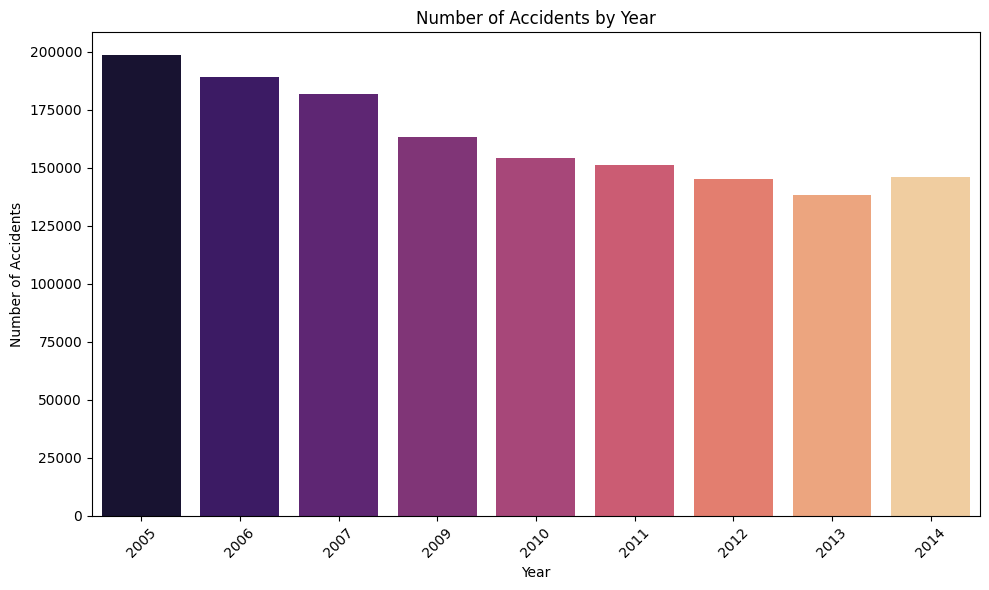

In [19]:
# Accidents by Year
accidents_by_year = df2.groupby('Year').size().reset_index(name='Number of Accidents')

plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Number of Accidents', data=accidents_by_year, palette='magma')
plt.title('Number of Accidents by Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4929/3740700046.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Number of Accidents', data=accidents_by_month, palette='magma')


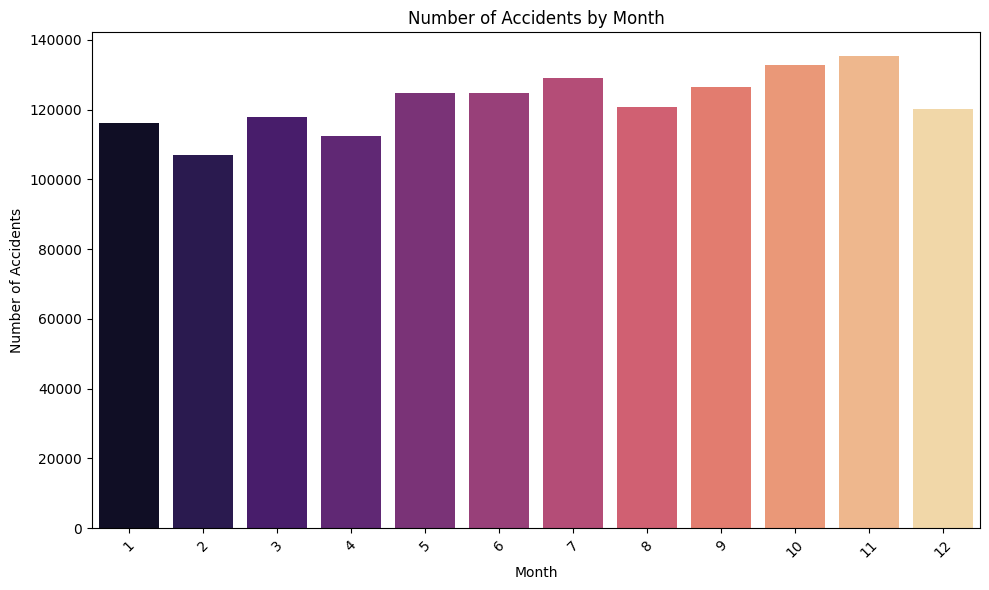

In [20]:
# Accidents by Month
accidents_by_month = df2.groupby('Month').size().reset_index(name='Number of Accidents')

plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Number of Accidents', data=accidents_by_month, palette='magma')
plt.title('Number of Accidents by Month')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4929/2388943889.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Quarter', y='Number of Accidents', data=accidents_by_quarter, palette='magma')


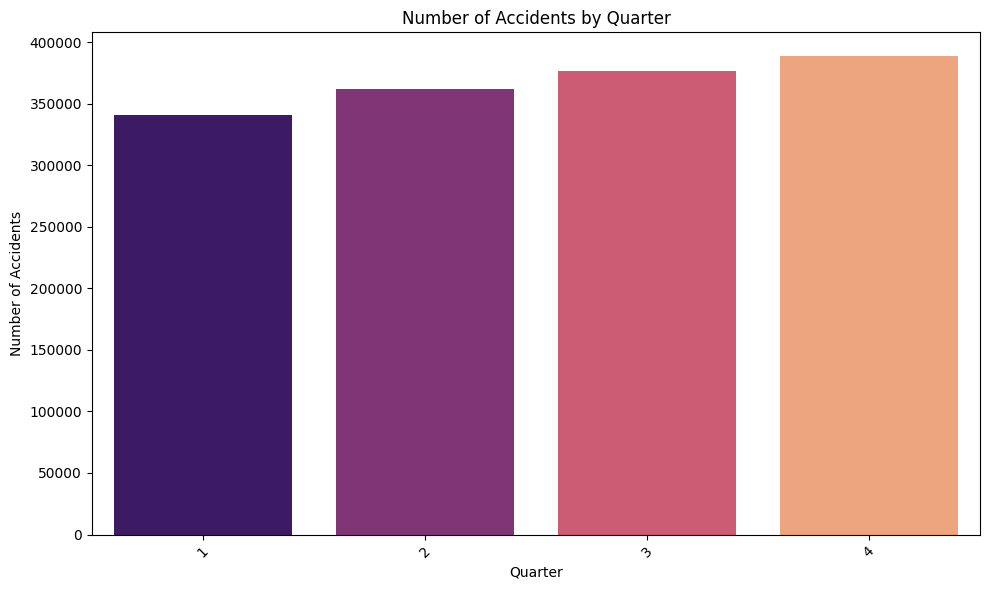

In [21]:
# Accidents by Quarter
accidents_by_quarter = df2.groupby('Quarter').size().reset_index(name='Number of Accidents')

plt.figure(figsize=(10, 6))
sns.barplot(x='Quarter', y='Number of Accidents', data=accidents_by_quarter, palette='magma')
plt.title('Number of Accidents by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

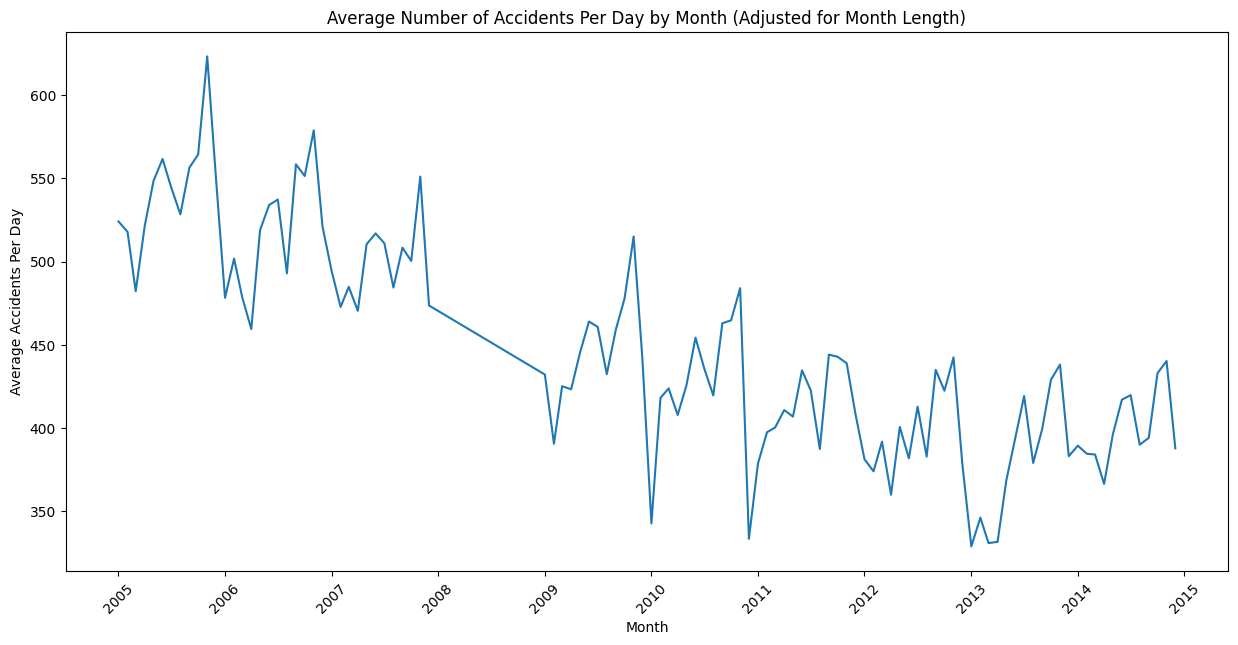

,Year,Month,Number_of_Accidents,Number_of_Days,Average_Accidents_Per_Day,Year_Month
0,2005,1,16246,31,524.064516,2005-01-01
1,2005,2,14500,28,517.857143,2005-02-01
2,2005,3,14947,31,482.161290,2005-03-01
3,2005,4,15645,30,521.500000,2005-04-01
4,2005,5,17001,31,548.419355,2005-05-01


In [22]:
# Calculate the number of accidents and unique days for each Year-Month combination
monthly_data = df2.groupby(['Year', 'Month']).agg(
    Number_of_Accidents=('Accident_Index', 'count'),
    Number_of_Days=('Day_of_month', 'nunique')
).reset_index()

# Calculate the average number of accidents per day for each month
monthly_data['Average_Accidents_Per_Day'] = monthly_data['Number_of_Accidents']/monthly_data['Number_of_Days']

# Create a datetime column for plotting
monthly_data['Year_Month'] = pd.to_datetime(monthly_data['Year'].astype(str) + '-' + monthly_data['Month'].astype(str))

# Sort by Year_Month for proper time series plotting
monthly_data = monthly_data.sort_values('Year_Month')

plt.figure(figsize=(15, 7))
sns.lineplot(x='Year_Month', y='Average_Accidents_Per_Day', data=monthly_data)
plt.title('Average Number of Accidents Per Day by Month (Adjusted for Month Length)')
plt.xlabel('Month')
plt.ylabel('Average Accidents Per Day')
plt.xticks(rotation=45)
plt.show()
monthly_data.head(5)

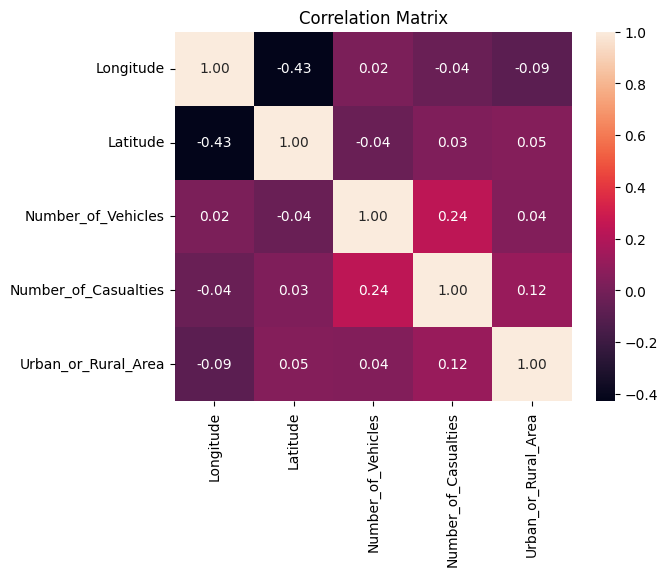

In [23]:
# Correlation matrix
numeric_cols = ['Longitude', 'Latitude', 'Number_of_Vehicles', 'Number_of_Casualties','Urban_or_Rural_Area']
correlation_matrix = df2[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


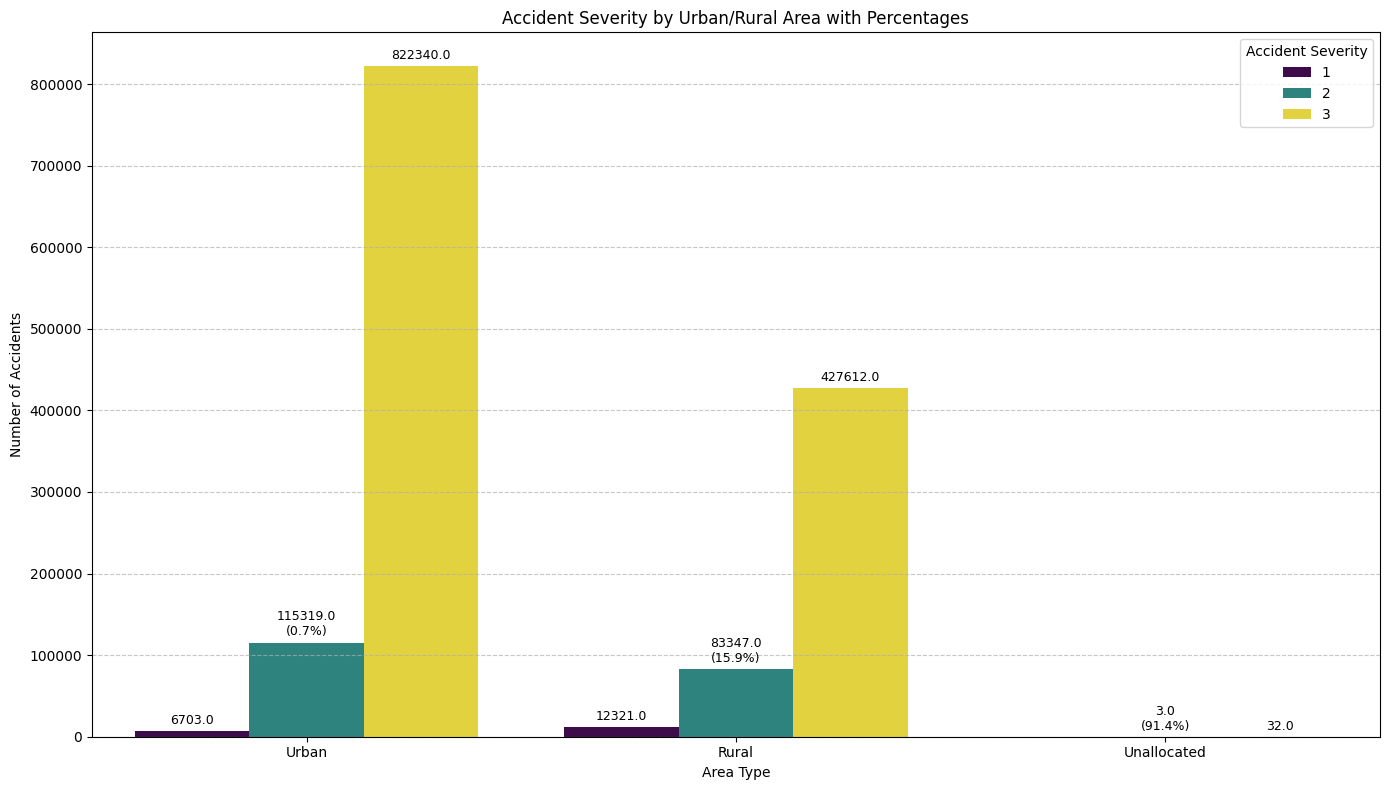

In [24]:
area_mapping = {1: 'Urban', 2: 'Rural', 3: 'Unallocated'}
df2['Urban_or_Rural_Area_Label'] = df2['Urban_or_Rural_Area'].map(area_mapping)

# Calculate counts for each group
counts = df2.groupby(['Urban_or_Rural_Area_Label', 'Accident_Severity']).size().unstack(fill_value=0)

# Calculate percentages
percentages = counts.apply(lambda x: x / x.sum() * 100, axis=1)

plt.figure(figsize=(14, 8))
ax = sns.countplot(data=df2, x='Urban_or_Rural_Area_Label', hue='Accident_Severity', palette='viridis')
plt.title('Accident Severity by Urban/Rural Area with Percentages')
plt.xlabel('Area Type')
plt.ylabel('Number of Accidents')
plt.legend(title='Accident Severity', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

for container in ax.containers:
    labels = []
    for i, p in enumerate(container.patches):
        area_label = p.get_x() + p.get_width() / 2  # Get x-coordinate of the bar center
        severity = ax.get_legend_handles_labels()[1][container.patches.index(p)] # Get severity from hue

        # Find the correct area label string for percentages
        area_idx = int(area_label) if area_label.is_integer() else area_label # handle float x-coords
        if area_idx == 0: area_str = 'Urban'
        elif area_idx == 1: area_str = 'Rural'
        elif area_idx == 2: area_str = 'Unallocated'
        else: area_str = ''

        count_val = p.get_height()
        if area_str in percentages.index and int(severity) in percentages.columns:
            percent_val = percentages.loc[area_str, int(severity)]
            labels.append(f'{count_val}\n({percent_val:.1f}%)')
        else:
            labels.append(f'{count_val}')

    ax.bar_label(container, labels=labels, fmt='', fontsize=9, padding=3)

plt.show()

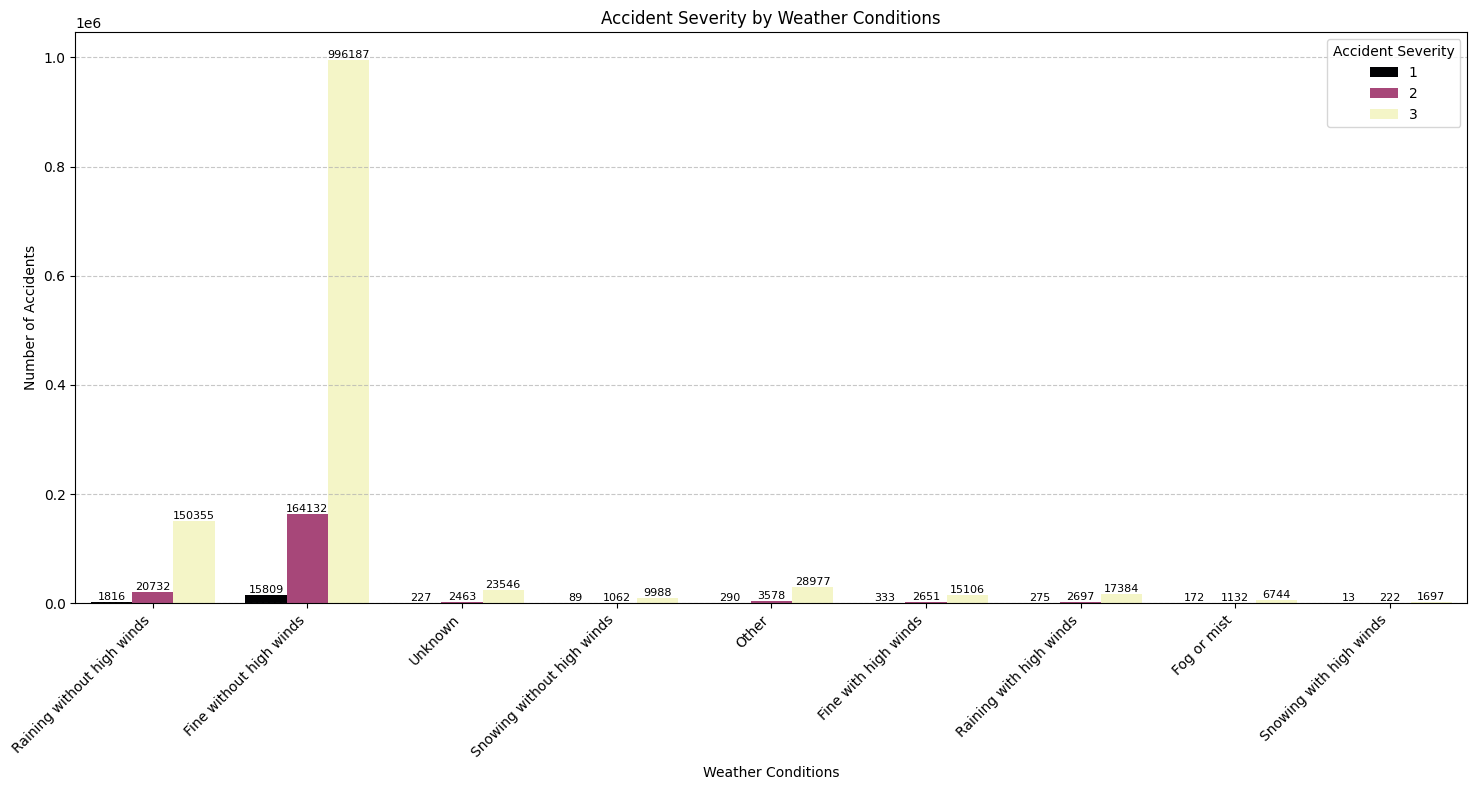

In [25]:
# Accident Severity by Weather Conditions
plt.figure(figsize=(15, 8))
ax = sns.countplot(data=df2, x='Weather_Conditions', hue='Accident_Severity', palette='magma')
plt.title('Accident Severity by Weather Conditions')
plt.xlabel('Weather Conditions')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Accident Severity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=8)
plt.show()

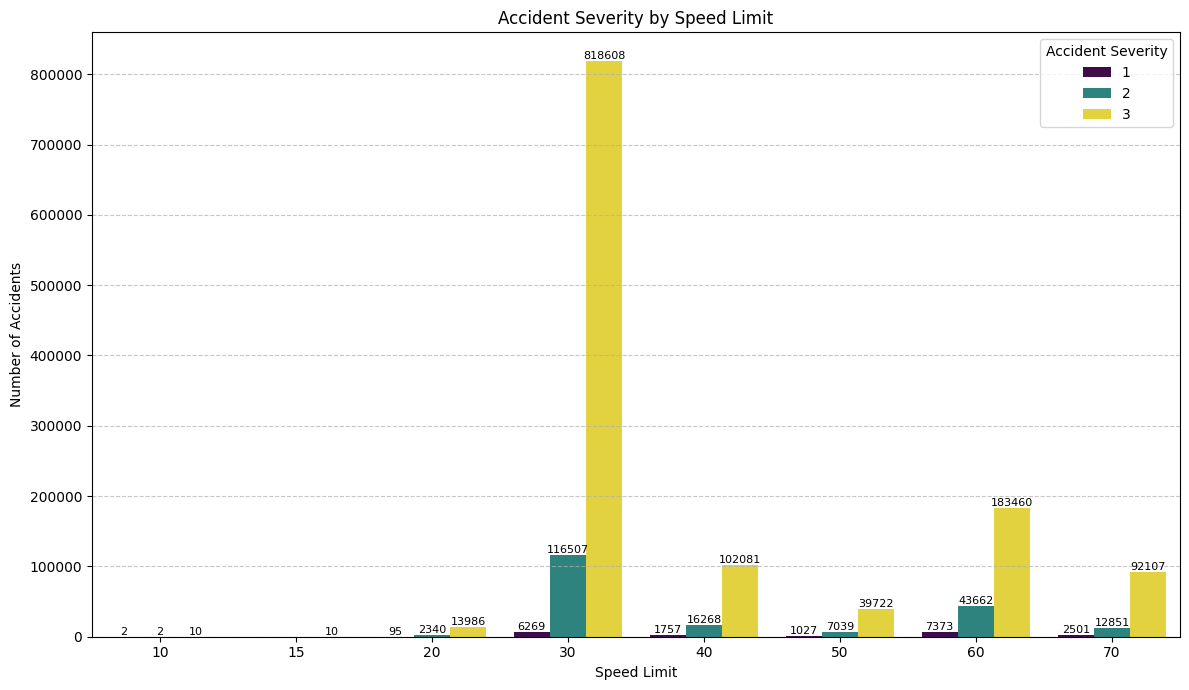

In [26]:
# Accident Severity by Speed Limit
plt.figure(figsize=(12, 7))
ax = sns.countplot(data=df2, x='Speed_limit', hue='Accident_Severity', palette='viridis')
plt.title('Accident Severity by Speed Limit')
plt.xlabel('Speed Limit')
plt.ylabel('Number of Accidents')
plt.legend(title='Accident Severity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=8)
plt.show()

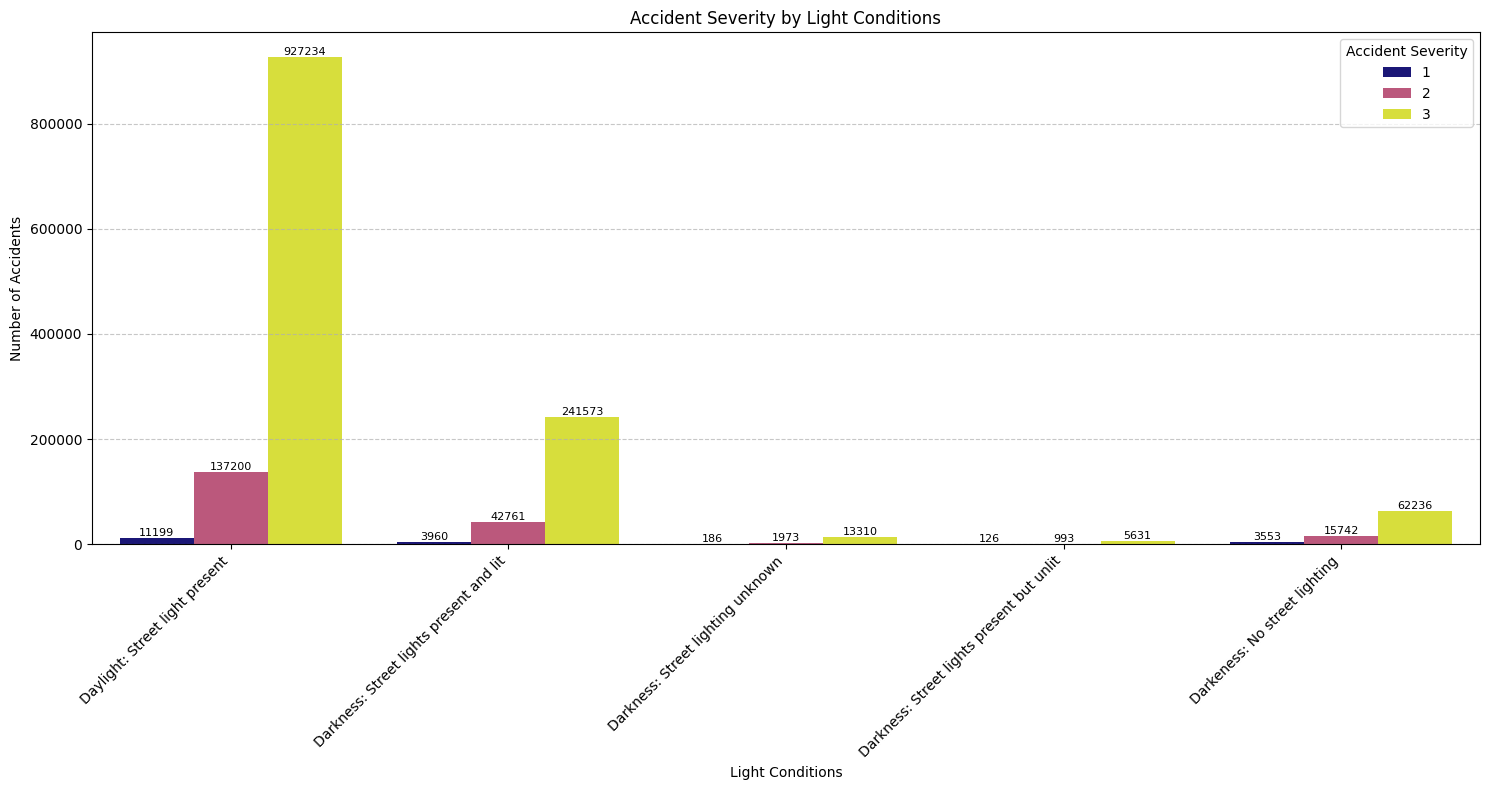

In [27]:
# Accident Severity by Light Conditions
plt.figure(figsize=(15, 8))
ax = sns.countplot(data=df2, x='Light_Conditions', hue='Accident_Severity', palette='plasma')
plt.title('Accident Severity by Light Conditions')
plt.xlabel('Light Conditions')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Accident Severity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=8)
plt.show()

https://www-sciencedirect-com.ezproxy.saimia.fi/science/article/pii/S0001457509003091
https://pmc.ncbi.nlm.nih.gov/articles/PMC10407198/

# PREDICTION

I will drop three columns 'Carriageway_Hazards','Special_Conditions_at_Site','Accident_Index', since the first two columns containing a highly large proportion of None value, so not contributing much to the prediction.

In [28]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1467677 entries, 0 to 1504149
Data columns (total 36 columns):
 #   Column                                       Non-Null Count    Dtype         
---  ------                                       --------------    -----         
 0   Accident_Index                               1467677 non-null  object        
 1   Location_Easting_OSGR                        1467677 non-null  float64       
 2   Location_Northing_OSGR                       1467677 non-null  float64       
 3   Longitude                                    1467677 non-null  float64       
 4   Latitude                                     1467677 non-null  float64       
 5   Police_Force                                 1467677 non-null  int64         
 6   Accident_Severity                            1467677 non-null  int64         
 7   Number_of_Vehicles                           1467677 non-null  int64         
 8   Number_of_Casualties                         1467677 non-

In [29]:
light_map = {
    'Daylight: Street light present': 1,
    'Daylight: No street lighting': 2,
    'Daylight: Street lighting unknown': 3,
    'Darkness: Street lights present and lit': 4,
    'Darkness: Street lights present but unlit': 5,
    'Darkness: No street lighting': 6,
    'Darkeness: No street lighting': 6,         # typo in data
    'Darkness: Street lighting unknown': 7,
}

weather_map = {
    'Fine without high winds': 1,
    'Raining without high winds': 2,
    'Snowing without high winds': 3,
    'Fine with high winds': 4,
    'Raining with high winds': 5,
    'Snowing with high winds': 6,
    'Fog or mist': 7,
    'Other': 8,
    'Unknown': 9,
}

road_surface_map = {
    'Dry': 1,
    'Wet/Damp': 2,
    'Snow': 3,
    'Frost/Ice': 4,
    'Flood (Over 3cm of water)': 5,
}

special_conditions_map = {
    'None': 0,
    'Auto traffic singal out': 1,               # typo in data
    'Auto traffic signal out': 1,
    'Auto traffic signal partly defective': 2,
    'Permanent sign or marking defective or obscured': 3,  # variant label
    'Road signs defective or obscured': 3,
    'Roadworks': 4,
    'Road surface defective': 5,
    'Ol or diesel': 6,                          # typo in data
    'Oil or diesel': 6,
    'Mud': 7,
}

carriageway_map = {
    'None': 0,
    'Dislodged vehicle load in carriageway': 1,
    'Other object in carriageway': 2,
    'Involvement with previous accident': 3,
    'Pedestrian in carriageway (not injured)': 6,
    'Any animal (except a ridden horse)': 7,    # variant label
    'Any animal in carriageway (except ridden horse)': 7,
}

junction_control_map = {
    'None': 0,
    'Authorised person': 1,
    'Automatic traffic signal': 2,
    'Stop Sign': 3,
    'Giveway or uncontrolled': 4,
}

ped_human_map = {
    'None within 50 metres': 0,
    'Control by school crossing patrol': 1,
    'Control by other authorised person': 2,
}

ped_physical_map = {
    'No physical crossing within 50 meters': 0,
    'Zebra crossing': 1,
    'non-junction pedestrian crossing': 4,
    'Pedestrian phase at traffic signal junction': 5,
    'Footbridge or subway': 7,
    'Central refuge': 8,
}

police_map = {
    'Yes': 1,
    'No': 2,
    'Unknown': 3,
}

road_type_map = {
    'Roundabout': 1,
    'One way street': 2,
    'Dual carriageway': 3,
    'Single carriageway': 6,
    'Slip road': 7,
    'Unknown': 9,
}

# Apply all mappings
mapping_cols = {
    'Light_Conditions': light_map,
    'Weather_Conditions': weather_map,
    'Road_Surface_Conditions': road_surface_map,
    'Special_Conditions_at_Site': special_conditions_map,
    'Carriageway_Hazards': carriageway_map,
    'Junction_Control': junction_control_map,
    'Pedestrian_Crossing-Human_Control': ped_human_map,
    'Pedestrian_Crossing-Physical_Facilities': ped_physical_map,
    'Did_Police_Officer_Attend_Scene_of_Accident': police_map,
    'Road_Type': road_type_map,
}

for col, mapping in mapping_cols.items():
    df2[f"{col}_code"] = df2[col].map(mapping)


In [31]:
# df2.drop(columns  = ["Carriageway_Hazards", "Special_Conditions_at_Site","Accident_Index"], inplace = True)

In [32]:
# join location data into accident data for more features
# Use Duc's code, thanks a lot :D
import geopandas as gpd
from shapely.geometry import Point

districts = gpd.read_file('/content/drive/MyDrive/UK_accident/lsoa.geojson')


geometry = [Point(xy) for xy in zip(df2['Longitude'], df2['Latitude'])]
gdf_accidents = gpd.GeoDataFrame(df2, geometry=geometry, crs="EPSG:4326")

districts = districts.to_crs("EPSG:4326")

df_mapped = gpd.sjoin(gdf_accidents, districts, how="left", predicate="within")

print(df_mapped.head())

  Accident_Index  Location_Easting_OSGR  Location_Northing_OSGR  Longitude  \
0  200501BS00001               525680.0                178240.0  -0.191170   
1  200501BS00002               524170.0                181650.0  -0.211708   
2  200501BS00003               524520.0                182240.0  -0.206458   
3  200501BS00004               526900.0                177530.0  -0.173862   
4  200501BS00005               528060.0                179040.0  -0.156618   

    Latitude  Police_Force  Accident_Severity  Number_of_Vehicles  \
0  51.489096             1                  2                   1   
1  51.520075             1                  3                   1   
2  51.525301             1                  3                   2   
3  51.482442             1                  3                   1   
4  51.495752             1                  3                   1   

   Number_of_Casualties       Date  ...  objectid    lad16cd  \
0                     1 2005-01-04  ...     313.0  E

In [33]:
# # Drop unneeded locations features
# df_mapped.drop(columns = ['geometry', 'index_right',
#        'objectid', 'bng_e', 'bng_n', 'long',
#        'lat', 'st_areashape', 'st_lengthshape','Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude',
#        'Latitude','lad16cd', 'lad16nm', 'lad16nmw'], inplace = True)
# df_mapped.isna().sum()

In [34]:
# print('\n' + ('=' * 40))
# print(f"Feature: lad16nm ")
# print('-' * 40)
# print(df_mapped["lad16nm"].value_counts(dropna=False))
# print("Percentage of null value of lad16nm feature", df_mapped["lad16nm"].isna().sum()/df_mapped["lad16nm"].size*100, "%")

In [35]:
df_mapped.isnull().sum()

,0
Accident_Index,0
Location_Easting_OSGR,0
Location_Northing_OSGR,0
Longitude,0
Latitude,0
Police_Force,0
Accident_Severity,0
Number_of_Vehicles,0
Number_of_Casualties,0
Date,0


In [36]:
df_mapped.dropna(inplace = True)

## Feature Engineering:

In [37]:
# Create more time feature
df_mapped['Time'] = pd.to_datetime(df_mapped['Time'])
df_mapped["Accident_Hour"] = df_mapped["Time"].dt.hour
df_mapped["Is_weekend"] = df_mapped["Day_of_Week"].apply(lambda x: True if x in [1,7] else False)
df_mapped["sin_month"] = np.sin(2 * np.pi * df_mapped["Month"]/12)
df_mapped["cos_month"] = np.cos(2 * np.pi * df_mapped["Month"]/12)
df_mapped["sin_hour"] = np.sin(2 * np.pi * df_mapped["Accident_Hour"]/24)
df_mapped["cos_hour"] = np.cos(2 * np.pi * df_mapped["Accident_Hour"]/24)


/tmp/ipykernel_4929/2158350747.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_mapped['Time'] = pd.to_datetime(df_mapped['Time'])


In [38]:
# # More features relating to external conditions and severity.
# light_map = light_mapping = {
#     'Daylight: Street light present': 'lit',
#     'Darkness: Street lights present and lit': 'lit',
#     'Darkness: Street lighting unknown': 'unknown',
#     'Darkness: Street lights present but unlit': 'unlit',
#     'Darkeness: No street lighting': 'None'
# }
# df_mapped["Avg_casualties_per_vehicle"] =df_mapped["Number_of_Casualties"]/df_mapped["Number_of_Vehicles"]
# df_mapped["Is_dark"] = df_mapped["Light_Conditions"].str.contains("Darkness|Darkeness", na=False) # check if the accident is when it's dark or daylight
# # df_mapped["Is_dark"] = df_mapped["Is_dark"].apply(lambda x: 1 if x is True else 0)
# df_mapped["Street_light"] = df_mapped["Light_Conditions"].map(light_map) # check the street light conditions



In [39]:
# cols_to_drop_for_modeling = [
#     'Date', 'Time', 'Light_Conditions', # 'Light_Conditions' was used to derive 'Is_dark' and 'Street_light' above
#     'LSOA_of_Accident_Location', # High cardinality
#     'Local_Authority_(Highway)', # High cardinality
#     'Local_Authority_(District)', # High cardinality
#     '1st_Road_Number', # High cardinality
#     '2nd_Road_Number', # High cardinality
#     'Year', # its numerical value doesn't imply order
#     'Police_Force', # High cardinality, could be reflected in region/area.
#     'Accident_Hour', # included
#     'Month', # included
#     'Quarter'
#     ]
# df_mapped.drop(columns = cols_to_drop_for_modeling, inplace = True)


In [40]:
df_mapped.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1466290 entries, 0 to 1504149
Data columns (total 64 columns):
 #   Column                                            Non-Null Count    Dtype         
---  ------                                            --------------    -----         
 0   Accident_Index                                    1466290 non-null  object        
 1   Location_Easting_OSGR                             1466290 non-null  float64       
 2   Location_Northing_OSGR                            1466290 non-null  float64       
 3   Longitude                                         1466290 non-null  float64       
 4   Latitude                                          1466290 non-null  float64       
 5   Police_Force                                      1466290 non-null  int64         
 6   Accident_Severity                                 1466290 non-null  int64         
 7   Number_of_Vehicles                                1466290 non-null  int64         
 8  

In [47]:
features_to_use = [
    # Location
    'Longitude',
    'Latitude',


    # --- Temporal ---
    "Accident_Hour",        # time of day is strongly linked to severity
    "Day_of_Week",          # weekday vs weekend driving patterns
    # "Is_weekend",           # explicit weekend flag
    "Month",                # seasonal effects
    "sin_month",            # cyclic encoding of month (already computed)
    "cos_month",            # cyclic encoding of month
    "sin_hour",             # cyclic encoding of hour
    "cos_hour",             # cyclic encoding of hour

    # --- Road & Environment ---
    "Road_Type_code",                        # single carriageway, roundabout, etc.
    "Speed_limit",                           # higher speed → higher severity
    "Light_Conditions_code",                 # daylight vs dark
    "Weather_Conditions_code",               # rain, fog, snow, etc.
    "Road_Surface_Conditions_code",          # wet, icy, dry
    # "Special_Conditions_at_Site_code",       # roadworks, oil spills, etc.
    # "Carriageway_Hazards_code",              # objects on road, etc.

    # --- Junction & Crossing ---
    "Junction_Control_code",                         # give way, signals, etc.
    # "Pedestrian_Crossing-Human_Control_code",        # school crossing patrol, etc.
    "Pedestrian_Crossing-Physical_Facilities_code",  # zebra, pelican, etc.

    # --- Location & Area ---
    "Urban_or_Rural_Area",   # urban accidents tend to be less severe than rural
    "1st_Road_Class",        # motorway vs A-road vs B-road
    "2nd_Road_Class",        # secondary road class at junction

    # --- Incident Scale ---
    "Number_of_Vehicles",    # multi-vehicle crashes can be more severe
    "Number_of_Casualties",  # correlated with severity but be careful of leakage*

    # # --- Police Attendance ---
    # "Did_Police_Officer_Attend_Scene_of_Accident_code",  # proxy for severity
]

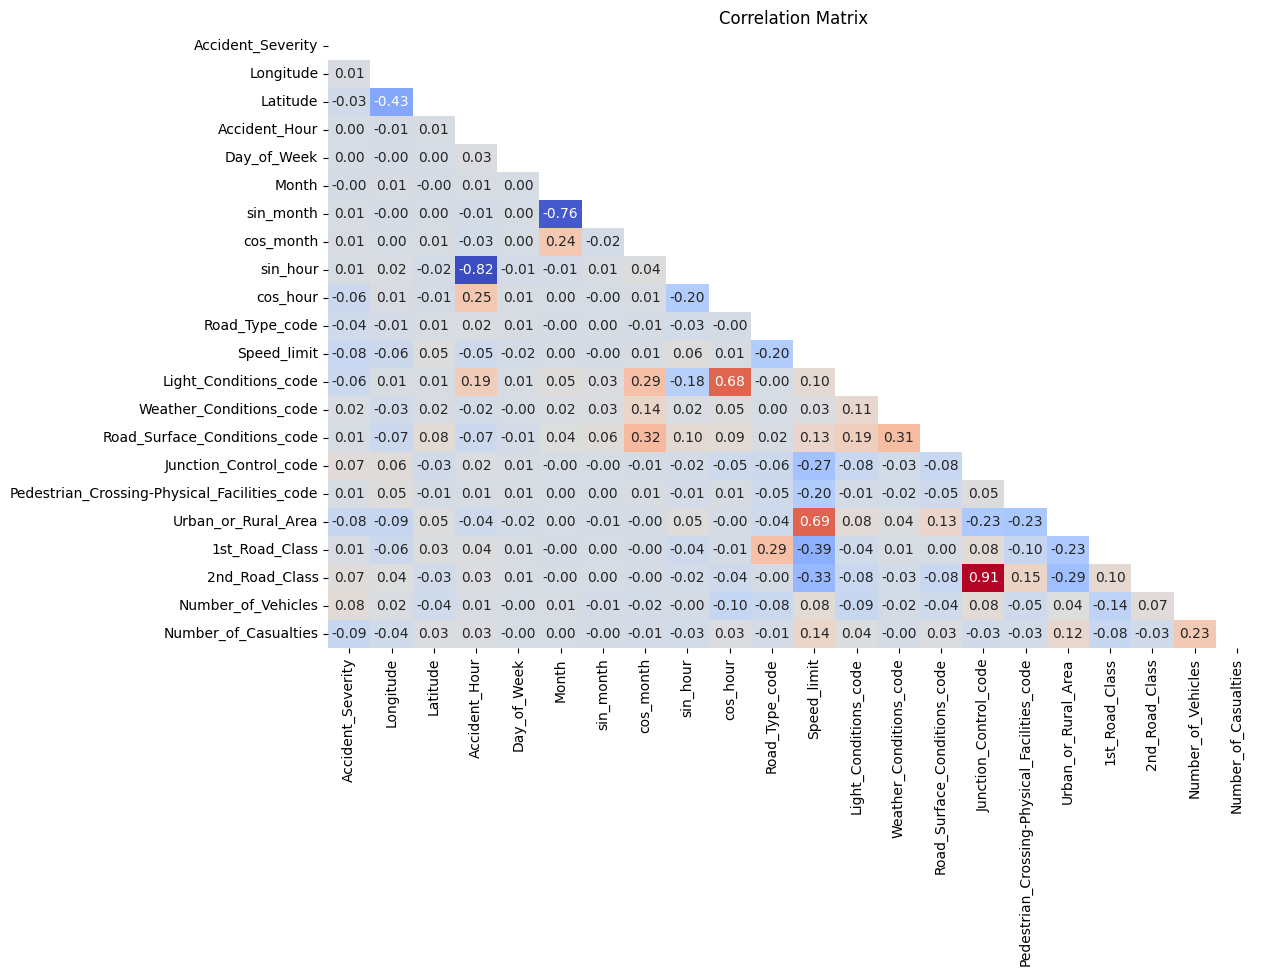

In [48]:
target = ['Accident_Severity']

matrix = df_mapped[target + features_to_use].corr()
mask = np.triu(np.ones_like(matrix, dtype=bool))

plt.figure(figsize = (12, 8))
sns.heatmap(matrix, mask = mask, annot = True,
            cmap = 'coolwarm', cbar = False, fmt = '.2f')
plt.title('Correlation Matrix')
plt.show()


In [49]:
# Remap before splitting
df_mapped["Risk_Flag"] = df_mapped["Accident_Severity"].map({
    1: 1,
    2: 1,
    3: 0,
})

print(df_mapped["Risk_Flag"].value_counts())

Risk_Flag
0    1248770
1     217520
Name: count, dtype: int64


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# The target variable
target = "Risk_Flag"
y = df_mapped[target].copy()
X = df_mapped[features_to_use].copy()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=8, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state = 8, stratify=y_temp)

print(X_train.shape, X_test.shape, X_val.shape)



(1026403, 21) (219944, 21) (219943, 21)


## Encode categorical features using label encoder

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTENC
import lightgbm as lgb


# binary_cols = ["Is_weekend"]

cyclic_cols = [
    "sin_month", "cos_month",
    "sin_hour",  "cos_hour",
]

ordinal_cols = [
    "Light_Conditions_code",
    "Weather_Conditions_code",
    "Road_Surface_Conditions_code",
    # "Special_Conditions_at_Site_code",
    # "Carriageway_Hazards_code",
    "Junction_Control_code",
    # "Pedestrian_Crossing-Human_Control_code",

    "Pedestrian_Crossing-Physical_Facilities_code",
    "Road_Type_code",
    "1st_Road_Class",
    "2nd_Road_Class",
    "Urban_or_Rural_Area",
    "Day_of_Week",
    "Month",
]

numeric_cols = [
    'Longitude',
    'Latitude',
    "Speed_limit",
    "Number_of_Vehicles",
    "Number_of_Casualties",
    "Accident_Hour",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("scale_numeric", StandardScaler(), numeric_cols),
        ("scale_cyclic",  StandardScaler(), cyclic_cols),
        # ("passthrough_binary",  "passthrough", binary_cols),
        ("passthrough_ordinal", "passthrough", ordinal_cols),
    ],
    remainder="drop"
)



In [52]:
feature_names = (
    numeric_cols +
    cyclic_cols  +
    # binary_cols  +
    ordinal_cols
)

# Wrap preprocessor outputs as DataFrames
X_train_pre = pd.DataFrame(
    preprocessor.fit_transform(X_train),
    columns=feature_names
)
X_val_pre = pd.DataFrame(
    preprocessor.transform(X_val),
    columns=feature_names
)
X_test_pre = pd.DataFrame(
    preprocessor.transform(X_test),
    columns=feature_names
)

In [56]:
X_train.columns

Index(['Longitude', 'Latitude', 'Accident_Hour', 'Day_of_Week', 'Month',
       'sin_month', 'cos_month', 'sin_hour', 'cos_hour', 'Road_Type_code',
       'Speed_limit', 'Light_Conditions_code', 'Weather_Conditions_code',
       'Road_Surface_Conditions_code', 'Junction_Control_code',
       'Pedestrian_Crossing-Physical_Facilities_code', 'Urban_or_Rural_Area',
       '1st_Road_Class', '2nd_Road_Class', 'Number_of_Vehicles',
       'Number_of_Casualties'],
      dtype='object')

In [57]:
X_train_pre.columns

Index(['Longitude', 'Latitude', 'Speed_limit', 'Number_of_Vehicles',
       'Number_of_Casualties', 'Accident_Hour', 'sin_month', 'cos_month',
       'sin_hour', 'cos_hour', 'Light_Conditions_code',
       'Weather_Conditions_code', 'Road_Surface_Conditions_code',
       'Junction_Control_code', 'Pedestrian_Crossing-Physical_Facilities_code',
       'Road_Type_code', '1st_Road_Class', '2nd_Road_Class',
       'Urban_or_Rural_Area', 'Day_of_Week', 'Month'],
      dtype='object')

In [53]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

scale_pos_weight: 5.7409


In [66]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=8,
        n_jobs=-1,
    ),

    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        scale_pos_weight=scale_pos_weight,
        n_estimators=300,
        learning_rate=0.05,

        random_state=8,
        n_jobs=-1,
        early_stopping_rounds=20,
    ),

}

fit_params = {
    "Logistic Regression": {},

    "XGBoost": {
        "eval_set": [(X_val_pre, y_val)],
        "verbose": 50,
    },

}

## Train Models

Data is imbalanced. Use Smote to balance the data

In [67]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

val_predictions = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print(f"{'='*50}")

    # Select correct labels for XGBoost (0-indexed)

    # Fit
    model.fit(X_train_pre, y_train, **fit_params[name])

    # Predict
    y_pred = model.predict(X_val_pre)

    # Store results
    val_predictions[name] = {
        "y_pred": y_pred,
        "y_true": y_val,
        "f1_weighted": f1_score(y_val, y_pred, average="weighted"),
        "f1_macro":    f1_score(y_val, y_pred, average="macro"),
        "confusion_matrix": confusion_matrix(y_val, y_pred),
    }

    # Print report
    target_names = (
        ["Slight(0)", "Serious(1)"]
    )
    print(f"\nClassification Report — {name}")
    print(classification_report(y_val, y_pred, target_names=target_names))
    print(f"Weighted F1 : {val_predictions[name]['f1_weighted']:.4f}")
    print(f"Macro F1    : {val_predictions[name]['f1_macro']:.4f}")

print(f"\n{'='*50}")
print("Validation Summary")
print(f"{'='*50}")
print(f"{'Model':<25} {'Weighted F1':>12} {'Macro F1':>10}")
print("-" * 50)
for name, result in val_predictions.items():
    print(f"{name:<25} {result['f1_weighted']:>12.4f} {result['f1_macro']:>10.4f}")


Training: Logistic Regression

Classification Report — Logistic Regression
              precision    recall  f1-score   support

   Slight(0)       0.89      0.62      0.73    187315
  Serious(1)       0.21      0.58      0.31     32628

    accuracy                           0.61    219943
   macro avg       0.55      0.60      0.52    219943
weighted avg       0.79      0.61      0.67    219943

Weighted F1 : 0.6678
Macro F1    : 0.5191

Training: XGBoost
[0]	validation_0-auc:0.65056
[50]	validation_0-auc:0.67029
[100]	validation_0-auc:0.67575
[150]	validation_0-auc:0.67825
[200]	validation_0-auc:0.67960
[250]	validation_0-auc:0.68037
[299]	validation_0-auc:0.68092

Classification Report — XGBoost
              precision    recall  f1-score   support

   Slight(0)       0.91      0.65      0.76    187315
  Serious(1)       0.23      0.62      0.34     32628

    accuracy                           0.64    219943
   macro avg       0.57      0.63      0.55    219943
weighted avg     

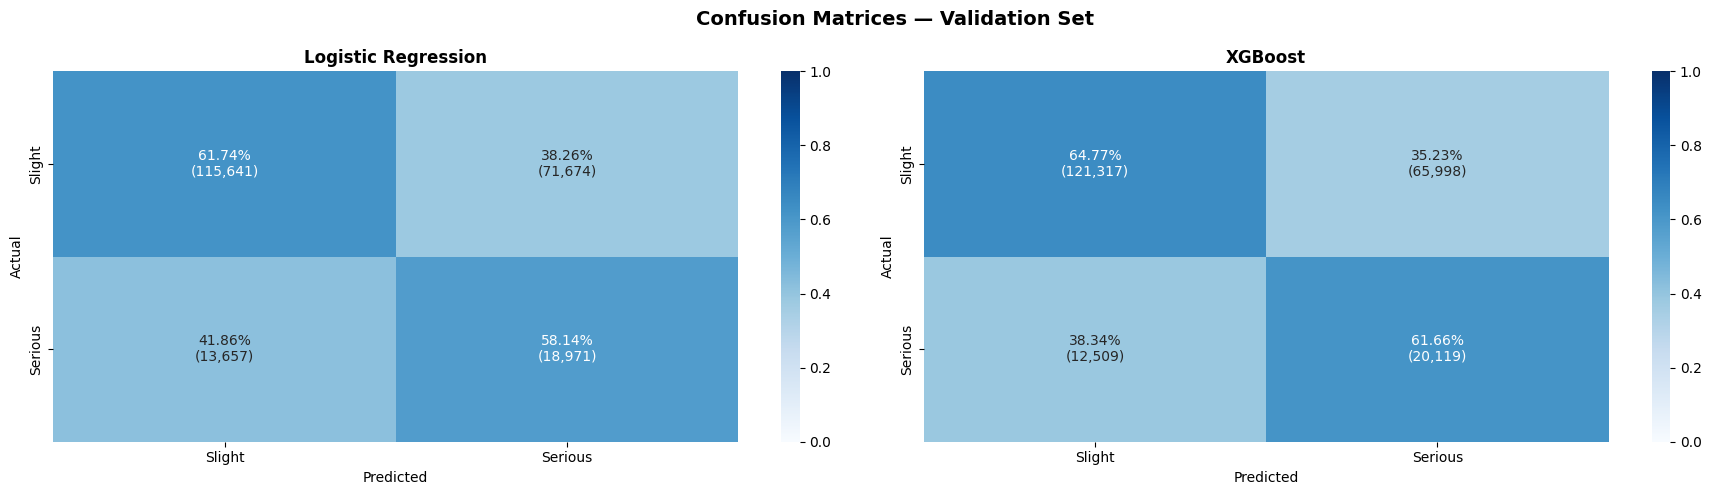

In [69]:
class_labels = ["Slight", "Serious"]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("Confusion Matrices — Validation Set", fontsize=14, fontweight="bold")

for ax, (name, result) in zip(axes, val_predictions.items()):
    cm = result["confusion_matrix"]
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_normalized,
        annot=np.array([[f"{v:.2%}\n({r:,})" for v, r in zip(row_n, row_r)]
                        for row_n, row_r in zip(cm_normalized, cm)]),
        fmt="",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=ax,
        vmin=0, vmax=1,
        cbar=True,
    )
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual", fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4929/786282357.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


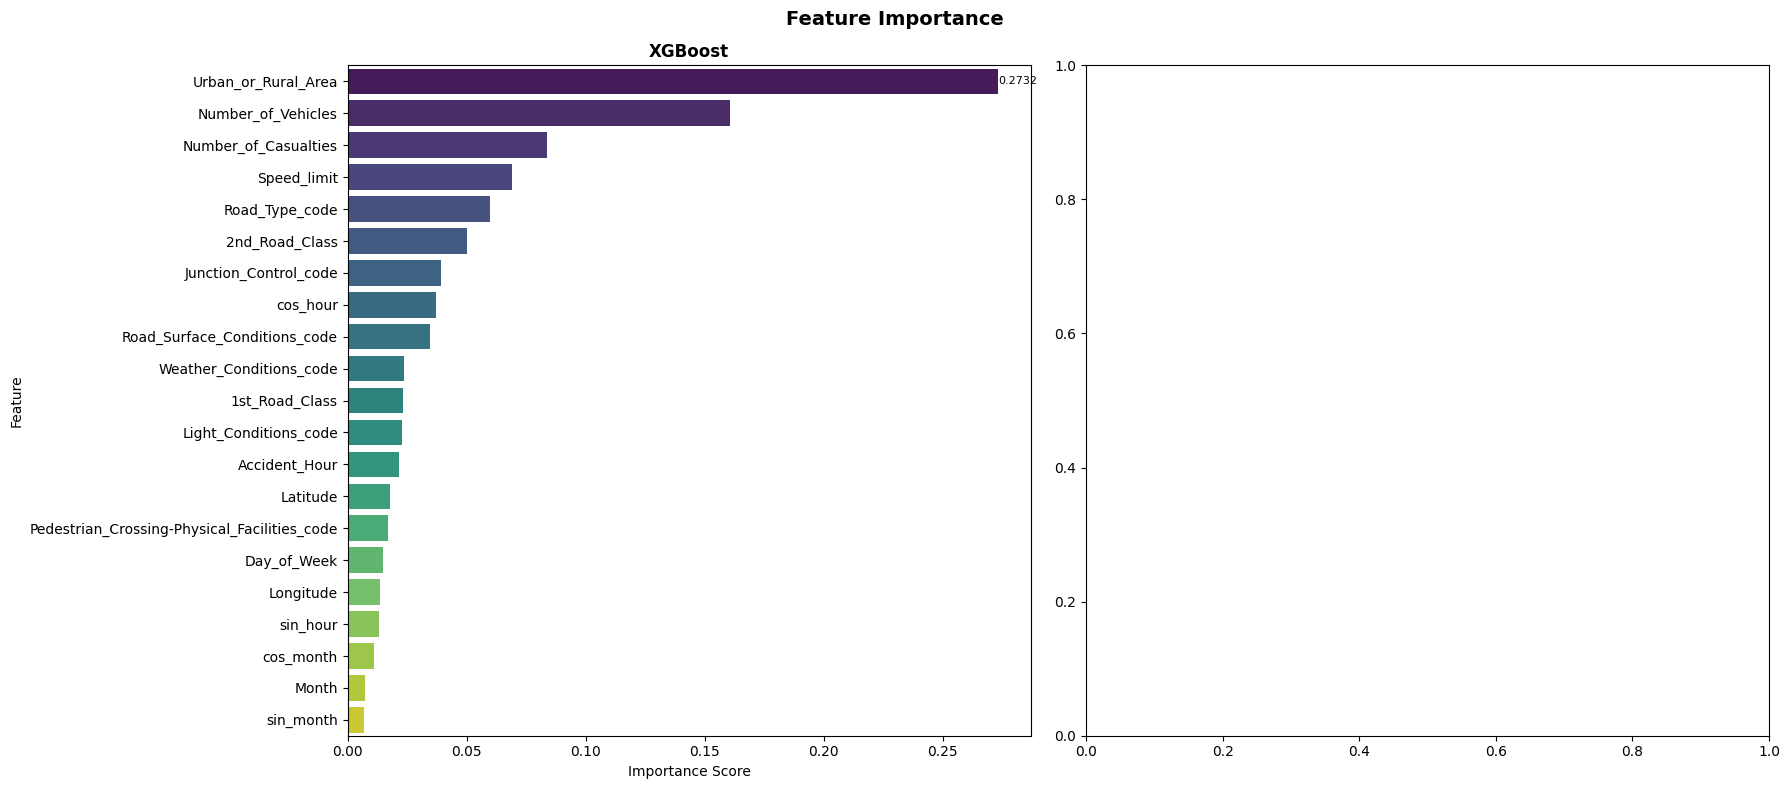

In [70]:


feature_names = (
    numeric_cols +
    cyclic_cols  +
    # binary_cols  +   # 1
    ordinal_cols
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Feature Importance", fontsize=14, fontweight="bold")

for ax, name in zip(axes, ["XGBoost"]):
    model     = models[name]
    importances = model.feature_importances_

    # Sort descending
    indices = np.argsort(importances)[::-1]
    sorted_features    = [feature_names[i] for i in indices]
    sorted_importances = importances[indices]

    sns.barplot(
        x=sorted_importances,
        y=sorted_features,
        palette="viridis",
        ax=ax,
    )
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Importance Score", fontsize=10)
    ax.set_ylabel("Feature", fontsize=10)
    ax.bar_label(ax.containers[0], fmt="%.4f", fontsize=8)

plt.tight_layout()
plt.show()

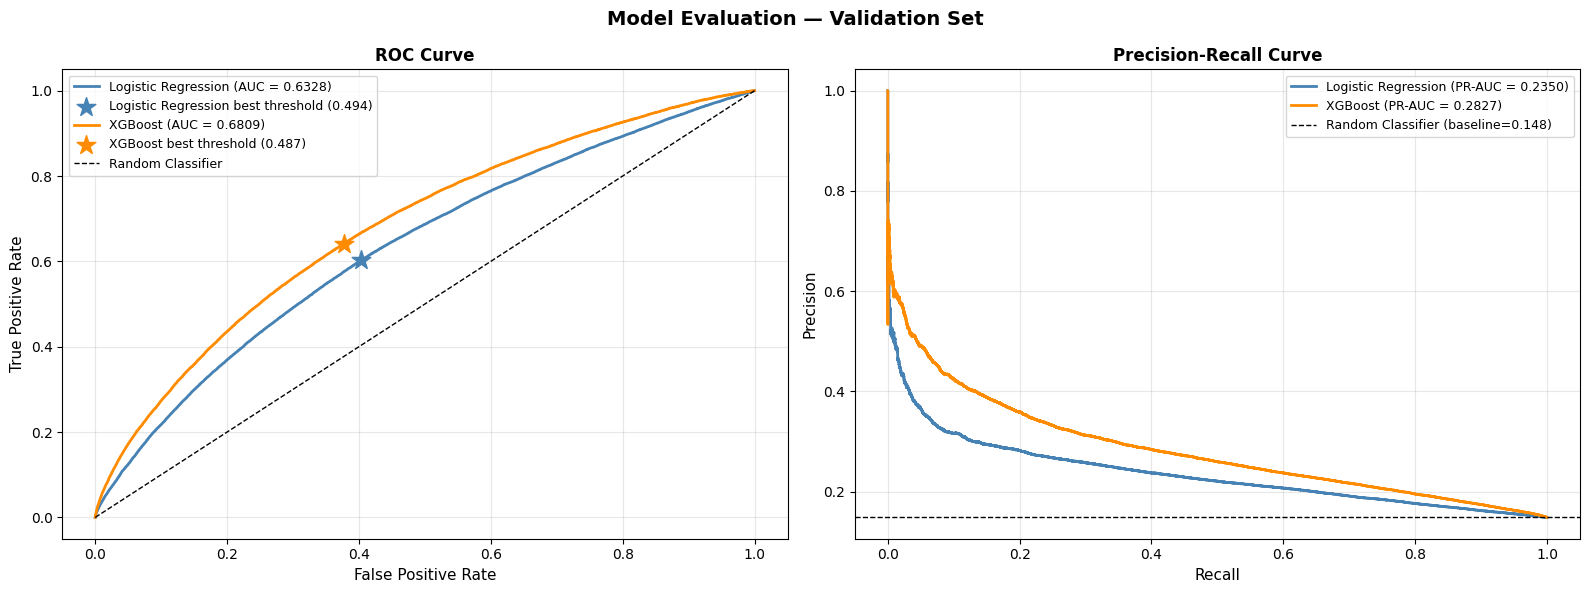

In [72]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

proba_val_predictions = {}


for name, model in models.items():
    y_pred_proba = model.predict_proba(X_val_pre)[:, 1]

    # ROC curve
    fpr, tpr, roc_thresholds = roc_curve(y_val, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Precision-Recall curve
    precision, recall, pr_thresholds = precision_recall_curve(y_val, y_pred_proba)
    pr_auc = average_precision_score(y_val, y_pred_proba)

    # Best threshold via Youden's J statistic (maximizes TPR - FPR)
    youden_j       = tpr - fpr
    best_idx       = np.argmax(youden_j)
    best_threshold = roc_thresholds[best_idx]

    # Apply best threshold
    y_pred_best = (y_pred_proba >= best_threshold).astype(int)

    proba_val_predictions[name] = {
        "y_pred_proba":  y_pred_proba,
        "best_threshold": best_threshold,
        "y_pred_best":   y_pred_best,
        # ROC
        "fpr":     fpr,
        "tpr":     tpr,
        "roc_auc": roc_auc,
        # PR
        "precision": precision,
        "recall":    recall,
        "pr_auc":    pr_auc,
    }



fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Model Evaluation — Validation Set", fontsize=14, fontweight="bold")

colors = {"Logistic Regression": "steelblue", "XGBoost": "darkorange"}

# ROC
ax = axes[0]
for name, result in proba_val_predictions.items():
    ax.plot(
        result["fpr"], result["tpr"],
        label=f"{name} (AUC = {result['roc_auc']:.4f})",
        color=colors[name], linewidth=2
    )
    # Mark best threshold point
    best_idx = np.argmax(result["tpr"] - result["fpr"])
    ax.scatter(
        result["fpr"][best_idx], result["tpr"][best_idx],
        color=colors[name], marker="*", s=200, zorder=5,
        label=f"{name} best threshold ({result['best_threshold']:.3f})"
    )

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curve", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Precision-Recall
ax = axes[1]
for name, result in proba_val_predictions.items():
    ax.plot(
        result["recall"], result["precision"],
        label=f"{name} (PR-AUC = {result['pr_auc']:.4f})",
        color=colors[name], linewidth=2
    )

baseline = y_val.sum() / len(y_val)
ax.axhline(y=baseline, color="k", linestyle="--", linewidth=1,
           label=f"Random Classifier (baseline={baseline:.3f})")
ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision-Recall Curve", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [77]:
from sklearn.metrics import roc_auc_score

test_predictions = {}

for name, result in proba_val_predictions.items():
    y_test_proba = models[name].predict_proba(X_test_pre)[:, 1]
    y_test_pred  = (y_test_proba >= result["best_threshold"]).astype(int)

    test_predictions[name] = {
        "y_pred":       y_test_pred,
        "y_pred_proba": y_test_proba,
        "y_true":       y_test,
        "f1_weighted":  f1_score(y_test, y_test_pred, average="weighted"),
        "f1_macro":     f1_score(y_test, y_test_pred, average="macro"),
        "roc_auc":      roc_auc_score(y_test, y_test_proba),
        "confusion_matrix": confusion_matrix(y_test, y_test_pred),
    }

    print(f"\n{'='*50}")
    print(f"Test Results: {name}")
    print(f"Threshold   : {result['best_threshold']:.4f}")
    print(f"{'='*50}")
    print(classification_report(
        y_test, y_test_pred,
        target_names=["Slight (0)", "High Risk (1)"]
    ))
    print(f"Weighted F1 : {test_predictions[name]['f1_weighted']:.4f}")
    print(f"Macro F1    : {test_predictions[name]['f1_macro']:.4f}")
    print(f"ROC-AUC     : {test_predictions[name]['roc_auc']:.4f}")




Test Results: Logistic Regression
Threshold   : 0.4943
               precision    recall  f1-score   support

   Slight (0)       0.90      0.60      0.72    187316
High Risk (1)       0.21      0.60      0.31     32628

     accuracy                           0.60    219944
    macro avg       0.55      0.60      0.51    219944
 weighted avg       0.79      0.60      0.66    219944

Weighted F1 : 0.6556
Macro F1    : 0.5120
ROC-AUC     : 0.6327

Test Results: XGBoost
Threshold   : 0.4874
               precision    recall  f1-score   support

   Slight (0)       0.91      0.62      0.74    187316
High Risk (1)       0.23      0.64      0.34     32628

     accuracy                           0.63    219944
    macro avg       0.57      0.63      0.54    219944
 weighted avg       0.81      0.63      0.68    219944

Weighted F1 : 0.6790
Macro F1    : 0.5375
ROC-AUC     : 0.6792


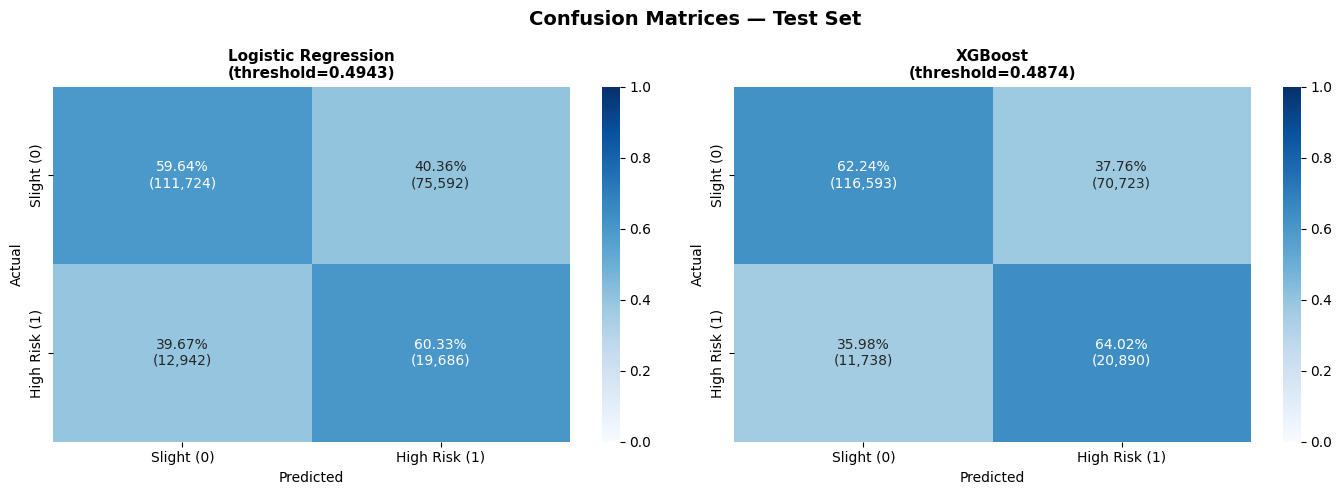

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrices — Test Set", fontsize=14, fontweight="bold")

for ax, (name, result) in zip(axes, test_predictions.items()):
    cm            = result["confusion_matrix"]
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_normalized,
        annot=np.array([
            [f"{v:.2%}\n({r:,})" for v, r in zip(row_n, row_r)]
            for row_n, row_r in zip(cm_normalized, cm)
        ]),
        fmt="",
        cmap="Blues",
        xticklabels=["Slight (0)", "High Risk (1)"],
        yticklabels=["Slight (0)", "High Risk (1)"],
        ax=ax,
        vmin=0, vmax=1,
        cbar=True,
    )
    ax.set_title(
        f"{name}\n(threshold={proba_val_predictions[name]['best_threshold']:.4f})",
        fontsize=11, fontweight="bold"
    )
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual", fontsize=10)

plt.tight_layout()
plt.show()